In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [73]:
df = pd.read_csv('../data/final/final_dataset.csv')
X_train_text, X_test_text, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.15, stratify=df['label'], random_state=42)
vectorizer = TfidfVectorizer( min_df=2, max_df=0.95, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [74]:
svc = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
svc.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [75]:
train_df = pd.read_csv('../results/train_results.csv')
real_df = pd.read_csv('../results/real_results.csv')
final = train_df.merge(real_df, on='Model')

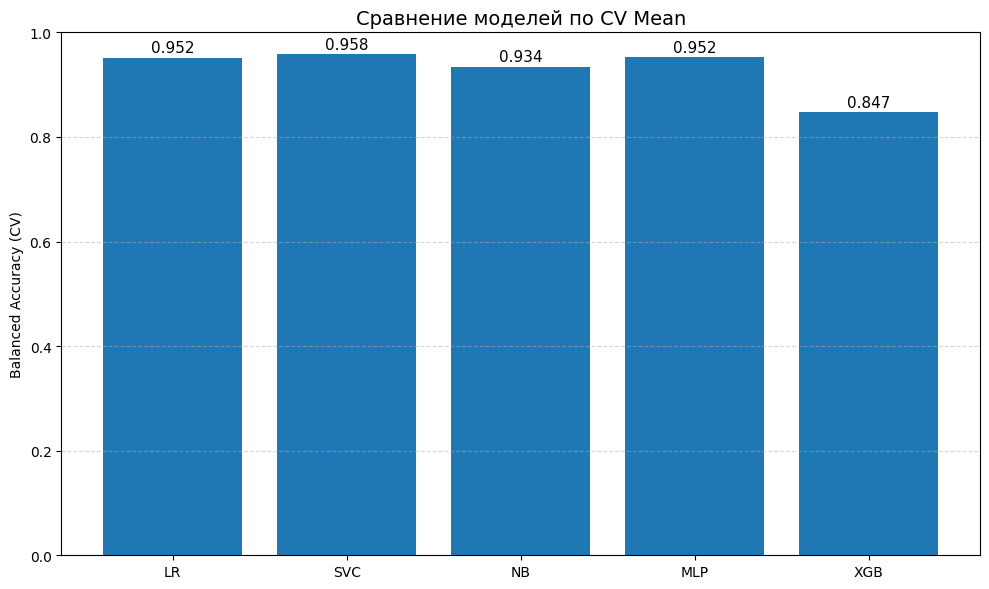

In [76]:
plt.figure(figsize=(10, 6))
plt.bar(final['Model'], final['CV Mean'])
plt.title('Сравнение моделей по CV Mean', fontsize=14)
plt.ylabel('Balanced Accuracy (CV)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(final['CV Mean']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../results/figures/models_comparison.png', dpi=150)
plt.show()

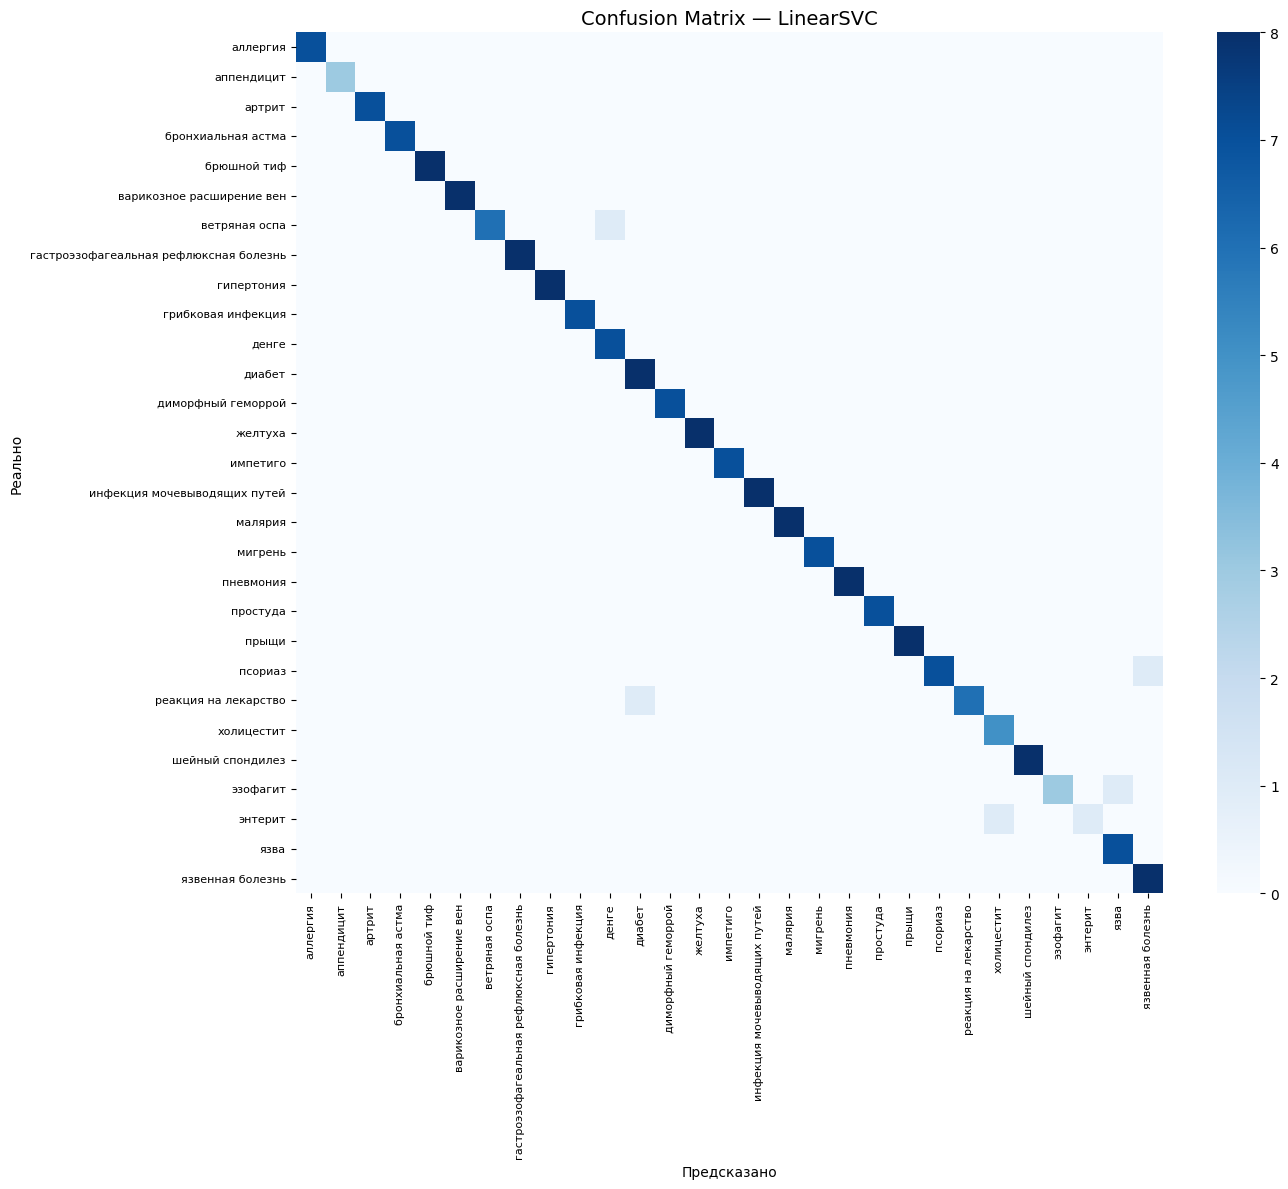

In [77]:
y_pred = svc.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, xticklabels=svc.classes_, yticklabels=svc.classes_, cmap='Blues')
plt.title('Confusion Matrix — LinearSVC', fontsize=14)
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix.png', dpi=150)
plt.show()

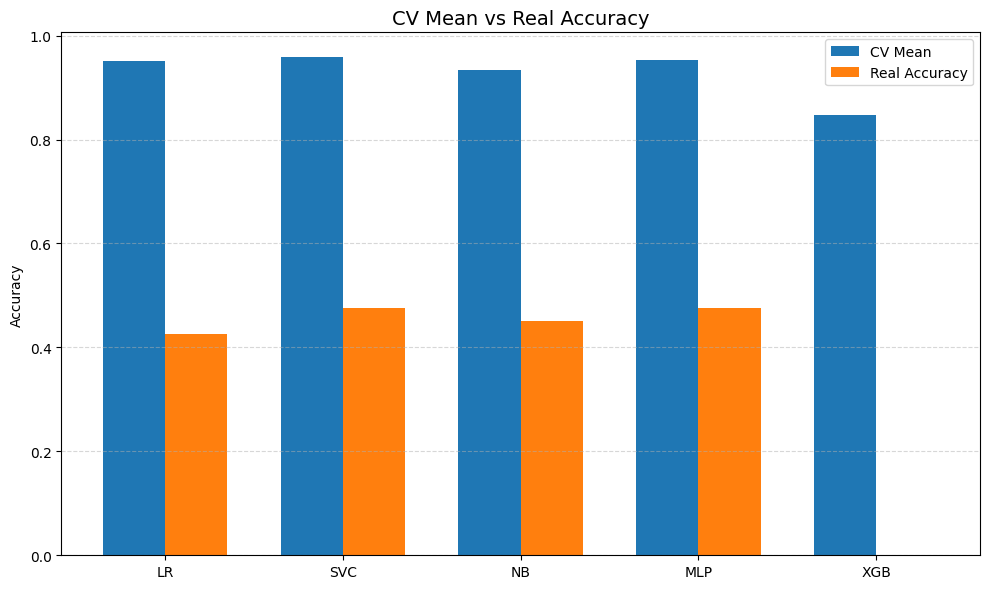

In [78]:
plt.figure(figsize=(10, 6))
x = range(len(final))
width = 0.35
plt.bar([i - width/2 for i in x], final['CV Mean'], width, label='CV Mean')
plt.bar([i + width/2 for i in x], final['Real Accuracy'], width, label='Real Accuracy')
plt.xticks(x, final['Model'])
plt.title('CV Mean vs Real Accuracy', fontsize=14)
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/cv_vs_real.png', dpi=150)
plt.show()

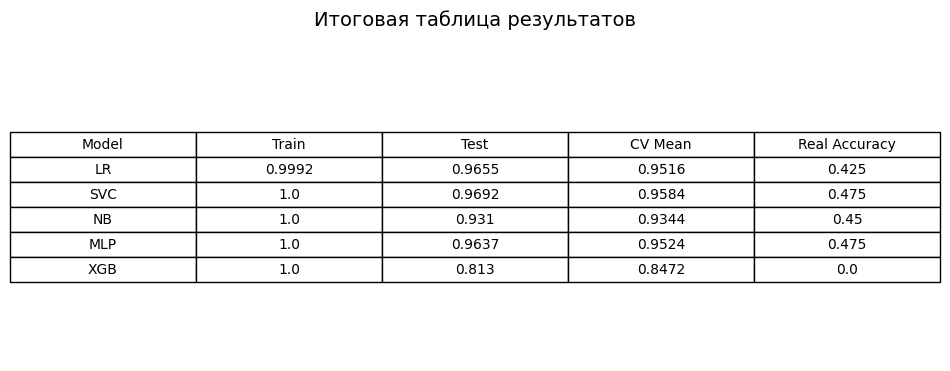

In [79]:
final = pd.read_csv('../results/final_results.csv')
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=final.values, colLabels=final.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('Итоговая таблица результатов', fontsize=14, pad=20)
plt.savefig('../results/tables/final_table.png', dpi=150, bbox_inches='tight')
plt.show()